In [1]:
"""Imports and global config — float64 throughout."""
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30
torch.set_default_dtype(DTYPE)
print(f"PyTorch {torch.__version__} | device={device} | dtype={DTYPE}")

PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}

_LOG_T0 = np.log(PARAMS['t_init'])   # -23.026
_LOG_T1 = np.log(PARAMS['t_end'])    # 0
_LOG_DT = _LOG_T1 - _LOG_T0          # 23.026

# ── V13: sub-domain t ∈ [t_split_V13, t_end]  (τ_split = 0.50 → t ≈ 1e-5) ──
TAU_SPLIT     = 0.50
_LOG_T_SPLIT  = _LOG_T0 + TAU_SPLIT * _LOG_DT   # ln(t_split)
_SUB_LOG_DT   = _LOG_DT * (1.0 - TAU_SPLIT)     # = 0.50 * 23.026 = 11.513
T_SPLIT_NP    = float(np.exp(_LOG_T_SPLIT))      # ≈ 1e-5

def t_to_s(t_tensor):
    return (torch.log(torch.clamp(t_tensor, min=EPS)) - _LOG_T_SPLIT) / _SUB_LOG_DT

def s_to_t(s_tensor):
    return torch.exp(_LOG_T_SPLIT + s_tensor * _SUB_LOG_DT)

print(f"PARAMS defined.")
print(f"t_split (V13) = {T_SPLIT_NP:.3e}  (tau_split={TAU_SPLIT})")
print(f"sub_log_dt    = {_SUB_LOG_DT:.4f}")
print(f"ds/dt @ t_split = {1.0/(T_SPLIT_NP*_SUB_LOG_DT):.1f}")
print(f"ds/dt @ t=1e-3  = {1.0/(1e-3*_SUB_LOG_DT):.1f}  (V12 boundary: 145)")
print(f"ds/dt @ t=1e-4  = {1.0/(1e-4*_SUB_LOG_DT):.1f}")


PyTorch 2.12.0+cpu | device=cpu | dtype=torch.float64
PARAMS defined.
t_split (V13) = 1.000e-05  (tau_split=0.5)
sub_log_dt    = 11.5129
ds/dt @ t_split = 8685.9
ds/dt @ t=1e-3  = 86.9  (V12 boundary: 145)
ds/dt @ t=1e-4  = 868.6


In [2]:
# ── ODE reference ──────────────────────────────────────────────────────────────
def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_s   = max(a, 1e-30)
    rax   = 0.5*phi_dot**2 + 0.5*ma**2*phi**2
    E1    = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    da_dt = np.sqrt(max(E1, 0.0)/3.0)
    E2    = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2    = np.sqrt(max(E2, 0.0)/3.0)
    return [da_dt, phi_dot, -np.sqrt(3.0)*H2*phi_dot - ma**2*phi]

def solve_ode(params, n_eval=5000):
    t0 = params['t_init']; t1 = params['t_end']
    y0 = [params['a0'], params['phi0'], params['dphi0']]
    args = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t0), np.log10(t1), n_eval)
    print("Solving ODE reference (RK45)...")
    t0w = time.time()
    sol = solve_ivp(_ode_rhs, (t0, t1), y0, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done {time.time()-t0w:.2f}s | success={sol.success}")
    if not sol.success:
        warnings.warn(sol.message)
    return sol   # sol.y[0]=a(t), sol.y[1]=phi(t), sol.y[2]=dphi(t)


def physics_residuals(a, phi, dphi, da_dt, d_dphi_dt, ma, rho_m0, rho_r0, rho_L):
    """First-order residuals (no d2phi/dt2 required)."""
    sqrt3 = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rax   = 0.5*dphi**2 + 0.5*ma**2*phi**2
    a_s   = torch.clamp(a, min=EPS)
    E1    = rax + rho_m0/a_s   + rho_r0/a_s**2 + rho_L*a**2
    H1    = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F   = da_dt - H1
    E2    = rax + rho_m0/a_s**3 + rho_r0/a_s**4 + rho_L
    H2    = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG  = d_dphi_dt + sqrt3*H2*dphi + ma**2*phi
    return R_F, R_KG

print("ODE + physics residuals defined.")


ODE + physics residuals defined.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Architecture  (identical to V12 — parameterised by split point)
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, s):
        return self.net(s)


class ScaleFactorNet(nn.Module):
    """a(t) = a_split * exp(clamp(s*g(s), max=50)),  a(t_split)=a_split exactly."""
    def __init__(self, a_split, hidden=64, depth=5):
        super().__init__()
        self.register_buffer('log_a_split', torch.tensor(np.log(float(a_split)), dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def set_g_init(self, g_star):
        for m in reversed(list(self.net.net.modules())):
            if isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, float(g_star))
                break

    def forward(self, s):
        return torch.exp(self.log_a_split + torch.clamp(s * self.net(s), max=50.0))


class PhiNet(nn.Module):
    """phi = (A0 + s^2*fA(s))*cos(ma*t) + (B0 + s^2*fB(s))*sin(ma*t).  Hard IC at s=0."""
    def __init__(self, A0, B0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('A0', torch.tensor(float(A0), dtype=DTYPE))
        self.register_buffer('B0', torch.tensor(float(B0), dtype=DTYPE))
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_A = FCNN(1, 1, hidden, depth)
        self.net_B = FCNN(1, 1, hidden, depth)

    def forward(self, s, t):
        A = self.A0 + s**2 * self.net_A(s)
        B = self.B0 + s**2 * self.net_B(s)
        return A * torch.cos(self.ma * t) + B * torch.sin(self.ma * t)


class DPhiNet(nn.Module):
    """dphi = (C0 + s^2*fC(s))*cos(ma*t) + (D0 + s^2*fD(s))*sin(ma*t).  Hard IC at s=0."""
    def __init__(self, C0, D0, ma, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('C0', torch.tensor(float(C0), dtype=DTYPE))
        self.register_buffer('D0', torch.tensor(float(D0), dtype=DTYPE))
        self.register_buffer('ma', torch.tensor(float(ma), dtype=DTYPE))
        self.net_C = FCNN(1, 1, hidden, depth)
        self.net_D = FCNN(1, 1, hidden, depth)

    def forward(self, s, t):
        C = self.C0 + s**2 * self.net_C(s)
        D = self.D0 + s**2 * self.net_D(s)
        return C * torch.cos(self.ma * t) + D * torch.sin(self.ma * t)


class AxionPINN_V13(nn.Module):
    """Three-network PINN restricted to s in [0,1]  <->  t in [t_split, t_end]."""
    def __init__(self, a_split, A0, B0, C0, D0, ma,
                 a_hidden=64, a_depth=5, phi_hidden=64, phi_depth=4,
                 dphi_hidden=64, dphi_depth=4):
        super().__init__()
        self.register_buffer('_log_t_split', torch.tensor(_LOG_T_SPLIT, dtype=DTYPE))
        self.register_buffer('_sub_log_dt',  torch.tensor(_SUB_LOG_DT,  dtype=DTYPE))
        self.a_net    = ScaleFactorNet(a_split, a_hidden, a_depth)
        self.phi_net  = PhiNet(A0, B0, ma, phi_hidden, phi_depth)
        self.dphi_net = DPhiNet(C0, D0, ma, dphi_hidden, dphi_depth)

    def _to_s(self, t):
        return (torch.log(torch.clamp(t, min=EPS)) - self._log_t_split) / self._sub_log_dt

    def forward(self, t):
        s    = self._to_s(t)
        a    = self.a_net(s)
        phi  = self.phi_net(s, t)
        dphi = self.dphi_net(s, t)
        return a, phi, dphi


print("Classes defined: FCNN, ScaleFactorNet, PhiNet, DPhiNet, AxionPINN_V13")


Classes defined: FCNN, ScaleFactorNet, PhiNet, DPhiNet, AxionPINN_V13


In [4]:
import time as _time_mod

class AxionPINNSolver_V13:
    """
    V13: Extended sub-domain PINN covering t in [t_split_V13=1e-5, t_end=1].
    * t_split_V13 = 1e-5  (tau_split=0.50, sub_log_dt=11.513)
    * WKB hard ICs at t_split_V13 from ODE.
    * 5-stage curriculum (A→E) extending backward from s=0.80 to s=0.00.
    * Stages A and B are within V12's proven region (ds/dt < 90).
    * Stages D and E push into new territory (ds/dt up to 8686).
    * For t < t_split_V13: ODE interpolation.
    """

    def __init__(self, n_colloc=2000, hidden=64, depth_a=5, depth_phi=4, seed=42):
        torch.manual_seed(seed)
        np.random.seed(seed)

        # 1. ODE reference
        sol = solve_ode(PARAMS)
        self.t_ode    = sol.t
        self.a_ode    = sol.y[0]
        self.phi_ode  = sol.y[1]
        self.dphi_ode = sol.y[2]
        self.T_SPLIT  = float(np.exp(_LOG_T_SPLIT))

        # 2. ICs at t_split from ODE
        a_spl    = float(np.interp(self.T_SPLIT, self.t_ode, self.a_ode))
        phi_spl  = float(np.interp(self.T_SPLIT, self.t_ode, self.phi_ode))
        dphi_spl = float(np.interp(self.T_SPLIT, self.t_ode, self.dphi_ode))

        # 3. WKB rotation: exact IC recovery at s=0
        ma = PARAMS['ma']
        c  = ma * self.T_SPLIT       # ma*t_split = 0.001 (frozen era)
        A0 = phi_spl * np.cos(c) - (dphi_spl / ma) * np.sin(c)
        B0 = phi_spl * np.sin(c) + (dphi_spl / ma) * np.cos(c)
        C0 = B0 * ma
        D0 = -A0 * ma
        print(f"t_split_V13 = {self.T_SPLIT:.3e} | ma*t_split = {c:.4f} rad")
        print(f"A0={A0:.6f}  B0={B0:.6f}  C0={C0:.4e}  D0={D0:.4e}")
        print(f"IC check phi:  {A0*np.cos(c)+B0*np.sin(c):.8f}  (expect {phi_spl:.8f})")
        print(f"IC check dphi: {C0*np.cos(c)+D0*np.sin(c):.6e}  (expect {dphi_spl:.6e})")

        # 4. ODE-calibrated g_star for a_net (sub-domain only, t >= T_SPLIT)
        mask_sub  = self.t_ode >= self.T_SPLIT * 0.9999
        s_sub     = (np.log(self.t_ode[mask_sub]) - _LOG_T_SPLIT) / _SUB_LOG_DT
        log_a_rel = np.log(self.a_ode[mask_sub] / a_spl)
        g_star    = float(np.dot(s_sub, log_a_rel) / np.dot(s_sub, s_sub))
        print(f"g_star (V13 sub-domain) = {g_star:.4f}")

        # 5. Scales
        self.phi_scale  = float(max(np.max(np.abs(self.phi_ode)), 1e-4))
        self.dphi_scale = float(max(np.max(np.abs(self.dphi_ode[mask_sub])), 1e-4))
        print(f"phi_scale={self.phi_scale:.2f}  dphi_scale={self.dphi_scale:.3e}")

        # 6. Reference tensors (sub-domain only)
        t_sub = self.t_ode[mask_sub]
        self.t_ref_torch    = torch.tensor(t_sub[:, None],                  dtype=DTYPE)
        self.la_ref         = torch.tensor(np.log(self.a_ode[mask_sub, None]), dtype=DTYPE)
        self.phi_ref_torch  = torch.tensor(self.phi_ode[mask_sub, None],   dtype=DTYPE)
        self.dphi_ref_torch = torch.tensor(self.dphi_ode[mask_sub, None],  dtype=DTYPE)

        # 7. Build model
        self.model = AxionPINN_V13(
            a_split=a_spl, A0=A0, B0=B0, C0=C0, D0=D0, ma=ma,
            a_hidden=hidden, a_depth=depth_a,
            phi_hidden=hidden, phi_depth=depth_phi,
            dphi_hidden=hidden, dphi_depth=depth_phi,
        )
        self.model.a_net.set_g_init(g_star)
        self.n_colloc = n_colloc
        self.loss_log = []

    # ── collocation with curriculum support ──────────────────────────────
    def _make_colloc(self, n=None, s_min=0.0):
        if n is None:
            n = self.n_colloc
        s_b = s_min + (1.0 - s_min) * torch.rand(n, 1, dtype=DTYPE)
        return s_to_t(s_b).requires_grad_(True)

    # ── physics loss ──────────────────────────────────────────────────────
    def _physics_loss(self, t_col):
        p = PARAMS
        a, phi, dphi = self.model(t_col)
        ones      = torch.ones_like(a)
        da_dt     = torch.autograd.grad(a,    t_col, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d_dphi_dt = torch.autograd.grad(dphi, t_col, grad_outputs=ones, create_graph=True, retain_graph=True)[0]
        d_phi_dt  = torch.autograd.grad(phi,  t_col, grad_outputs=ones, create_graph=True)[0]
        R_F, R_KG = physics_residuals(
            a, phi, dphi, da_dt, d_dphi_dt,
            p['ma'], p['rho_m0'], p['rho_r0'], p['rho_L'])
        R_phi = d_phi_dt - dphi
        with torch.no_grad():
            a_d   = a.detach().clamp(min=EPS)
            rax_d = 0.5*dphi.detach()**2 + 0.5*p['ma']**2*phi.detach()**2
            E1_d  = rax_d + p['rho_m0']/a_d + p['rho_r0']/a_d**2 + p['rho_L']*a_d**2
            H_ref = torch.sqrt(torch.clamp(E1_d/3.0, min=1e-60))
        l_F   = torch.mean((R_F   / (H_ref + EPS))**2)
        l_KG  = torch.mean((R_KG  / (p['ma']**2 * self.phi_scale))**2)
        l_phi = torch.mean((R_phi / (self.dphi_scale + EPS))**2)
        return l_F, l_KG, l_phi

    # ── anchor loss ───────────────────────────────────────────────────────
    def _anchor_loss(self):
        a_p, phi_p, dphi_p = self.model(self.t_ref_torch)
        la_p = torch.log(torch.clamp(a_p, min=EPS))
        l_a    = torch.mean((la_p   - self.la_ref)**2)
        l_phi  = torch.mean((phi_p  - self.phi_ref_torch)**2)  / self.phi_scale**2
        l_dphi = torch.mean((dphi_p - self.dphi_ref_torch)**2) / self.dphi_scale**2
        return l_a + l_phi + l_dphi

    # ── pretrain ──────────────────────────────────────────────────────────
    def pretrain_a(self, epochs=8000, lr=1e-3, print_every=2000):
        opt = torch.optim.Adam(self.model.a_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"=== Pretrain a_net ({epochs} ep) ===")
        for ep in range(1, epochs+1):
            opt.zero_grad()
            s_v  = self.model._to_s(self.t_ref_torch)
            a_p  = self.model.a_net(s_v)
            loss = torch.mean((torch.log(torch.clamp(a_p, min=EPS)) - self.la_ref)**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss={loss.item():.3e}")
        with torch.no_grad():
            s_v = self.model._to_s(self.t_ref_torch)
            re  = (torch.exp(self.la_ref) - self.model.a_net(s_v)).abs() / torch.exp(self.la_ref).abs()
        print(f"  Done -- median {re.median().item():.3e}  max {re.max().item():.3e}")

    def pretrain_phi(self, epochs=5000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.phi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"=== Pretrain phi_net ({epochs} ep, WKB) ===")
        for ep in range(1, epochs+1):
            opt.zero_grad()
            s_v   = self.model._to_s(self.t_ref_torch)
            phi_p = self.model.phi_net(s_v, self.t_ref_torch)
            loss  = torch.mean((phi_p - self.phi_ref_torch)**2) / self.phi_scale**2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.phi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss={loss.item():.3e}")
        with torch.no_grad():
            s_v = self.model._to_s(self.t_ref_torch)
            re  = (self.phi_ref_torch - self.model.phi_net(s_v, self.t_ref_torch)).abs() / \
                  (self.phi_ref_torch.abs() + 1e-30)
        print(f"  Done -- median {re.median().item():.3e}  max {re.max().item():.3e}")

    def pretrain_dphi(self, epochs=5000, lr=1e-3, print_every=1000):
        opt = torch.optim.Adam(self.model.dphi_net.parameters(), lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        print(f"=== Pretrain dphi_net ({epochs} ep, WKB) ===")
        for ep in range(1, epochs+1):
            opt.zero_grad()
            s_v    = self.model._to_s(self.t_ref_torch)
            dphi_p = self.model.dphi_net(s_v, self.t_ref_torch)
            loss   = torch.mean((dphi_p - self.dphi_ref_torch)**2) / self.dphi_scale**2
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.dphi_net.parameters(), 1.0)
            opt.step(); sch.step()
            if ep % print_every == 0:
                print(f"  ep {ep:5d} | loss={loss.item():.3e}")
        with torch.no_grad():
            s_v = self.model._to_s(self.t_ref_torch)
            re  = (self.dphi_ref_torch - self.model.dphi_net(s_v, self.t_ref_torch)).abs() / \
                  (self.dphi_ref_torch.abs() + 1e-30)
        print(f"  Done -- median {re.median().item():.3e}  max {re.max().item():.3e}")

    # ── Adam stage with curriculum (s_min controls which region is trained) ─
    def _train_stage(self, label, epochs, lr, s_min,
                     lam_kg=10.0, lam_phi=0.1, lam_anc=0.1, print_every=None):
        opt   = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-6)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
        if print_every is None:
            print_every = max(1, epochs // 20)
        t_min_phys = float(s_to_t(torch.tensor([[s_min]])).item())
        dsdt_at_smin = 1.0 / (t_min_phys * _SUB_LOG_DT) if t_min_phys > 0 else float('inf')
        print(f"\n=== {label}  (s>={s_min:.2f}, t>={t_min_phys:.2e}, "
              f"ds/dt_left={dsdt_at_smin:.0f}, {epochs} ep, lr={lr:.1e}) ===")
        t0 = _time_mod.time()
        for ep in range(1, epochs+1):
            opt.zero_grad()
            t_col = self._make_colloc(s_min=s_min)
            l_F, l_KG, l_phi = self._physics_loss(t_col)
            l_anc = self._anchor_loss()
            loss  = l_F + lam_kg*l_KG + lam_phi*l_phi + lam_anc*l_anc
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            opt.step(); sched.step()
            self.loss_log.append({
                'ep': ep, 'label': label, 's_min': s_min,
                'F': l_F.item(), 'KG': l_KG.item(),
                'phi_cons': l_phi.item(), 'anc': l_anc.item(),
                'total': loss.item()
            })
            if ep % print_every == 0:
                print(f"  ep {ep:5d}/{epochs}  F={l_F.item():.2e}  "
                      f"KG={l_KG.item():.2e}  phi_cons={l_phi.item():.2e}  "
                      f"anc={l_anc.item():.2e}  t={_time_mod.time()-t0:.0f}s")

    # ── L-BFGS polish ─────────────────────────────────────────────────────
    def lbfgs_polish(self, max_iter=500, s_min=0.0,
                     lam_kg=10.0, lam_phi=1.0, lam_anc=0.1):
        print(f"\n=== L-BFGS Polish ({max_iter} iter, s>={s_min:.2f}) ===")
        opt   = torch.optim.LBFGS(self.model.parameters(), max_iter=max_iter,
                                   tolerance_grad=1e-9, history_size=50,
                                   line_search_fn='strong_wolfe')
        t_col = self._make_colloc(n=4000, s_min=s_min)
        _last = {}
        def closure():
            opt.zero_grad()
            l_F, l_KG, l_phi = self._physics_loss(t_col)
            l_anc = self._anchor_loss()
            loss  = l_F + lam_kg*l_KG + lam_phi*l_phi + lam_anc*l_anc
            loss.backward()
            _last.update({'F': l_F.item(), 'KG': l_KG.item(),
                          'phi': l_phi.item(), 'anc': l_anc.item()})
            return loss
        opt.step(closure)
        print(f"  Final: F={_last.get('F',float('nan')):.2e}  "
              f"KG={_last.get('KG',float('nan')):.2e}  "
              f"phi_cons={_last.get('phi',float('nan')):.2e}  "
              f"anc={_last.get('anc',float('nan')):.2e}")

    # ── full training pipeline (5-stage curriculum) ───────────────────────
    def train_all(self):
        t_wall = _time_mod.time()
        print("=" * 65)
        print("V13 Training  --  t in [1e-5, 1]  (5-stage curriculum)")
        print("=" * 65)

        # Pre-training (sub-domain ODE reference)
        print("\n[1/6] Pre-training")
        self.pretrain_a(epochs=8000,  lr=1e-3, print_every=2000)
        self.pretrain_phi(epochs=5000,  lr=1e-3, print_every=1000)
        self.pretrain_dphi(epochs=5000, lr=1e-3, print_every=1000)

        # Physics stages: gradually extend backward
        # Stage A: s >= 0.80 (t >= ~0.10, same as V12's well-trained late region)
        self._train_stage("Stage A (s>=0.80, t>=0.10)", epochs=5000, lr=5e-4,
                          s_min=0.80, lam_kg=10.0, lam_phi=0.1, lam_anc=0.5)

        # Stage B: s >= 0.60 (t >= ~0.01, oscillation onset, V12 region)
        self._train_stage("Stage B (s>=0.60, t>=0.01)", epochs=6000, lr=3e-4,
                          s_min=0.60, lam_kg=10.0, lam_phi=0.1, lam_anc=0.3)

        # Stage C: s >= 0.40 (t >= ~1e-3, V12 t_split boundary)
        self._train_stage("Stage C (s>=0.40, t>=1e-3)", epochs=8000, lr=2e-4,
                          s_min=0.40, lam_kg=10.0, lam_phi=0.1, lam_anc=0.2)

        # Stage D: s >= 0.20 (t >= ~1e-4, new V13 territory)
        self._train_stage("Stage D (s>=0.20, t>=1e-4)", epochs=8000, lr=1e-4,
                          s_min=0.20, lam_kg=10.0, lam_phi=0.1, lam_anc=0.2)

        # Stage E: full V13 domain s >= 0.00 (t >= 1e-5)
        self._train_stage("Stage E (s>=0.00, t>=1e-5)", epochs=10000, lr=5e-5,
                          s_min=0.00, lam_kg=10.0, lam_phi=0.1, lam_anc=0.1)

        # L-BFGS polish on full V13 domain
        self.lbfgs_polish(max_iter=500, s_min=0.00)

        print(f"\nTotal wall time: {(_time_mod.time()-t_wall)/60:.1f} min")

    # ── hybrid evaluation ─────────────────────────────────────────────────
    def evaluate(self, t_eval=None):
        """Hybrid: ODE for t < t_split_V13, PINN for t >= t_split_V13."""
        if t_eval is None:
            t_eval = np.logspace(
                np.log10(PARAMS['t_init']), np.log10(PARAMS['t_end']), 1000)
        a_pred    = np.empty_like(t_eval)
        phi_pred  = np.empty_like(t_eval)
        dphi_pred = np.empty_like(t_eval)
        mask_ode  = t_eval <  self.T_SPLIT
        mask_pinn = t_eval >= self.T_SPLIT
        if mask_ode.any():
            a_pred[mask_ode]    = np.interp(t_eval[mask_ode], self.t_ode, self.a_ode)
            phi_pred[mask_ode]  = np.interp(t_eval[mask_ode], self.t_ode, self.phi_ode)
            dphi_pred[mask_ode] = np.interp(t_eval[mask_ode], self.t_ode, self.dphi_ode)
        if mask_pinn.any():
            t_ptorch = torch.tensor(t_eval[mask_pinn, None], dtype=DTYPE)
            with torch.no_grad():
                ap, pp, dp = self.model(t_ptorch)
            a_pred[mask_pinn]    = ap.numpy().ravel()
            phi_pred[mask_pinn]  = pp.numpy().ravel()
            dphi_pred[mask_pinn] = dp.numpy().ravel()
        return t_eval, a_pred, phi_pred, dphi_pred


print("AxionPINNSolver_V13 defined")


AxionPINNSolver_V13 defined


In [5]:
def plot_comparison_v13(solver, save_dir='results_v13'):
    os.makedirs(save_dir, exist_ok=True)
    t_eval, a_pred, phi_pred, dphi_pred = solver.evaluate()
    t_ode, a_ode, phi_ode, dphi_ode = solver.t_ode, solver.a_ode, solver.phi_ode, solver.dphi_ode
    T_SPLIT = solver.T_SPLIT
    mask_pinn = t_eval >= T_SPLIT

    a_ref    = np.interp(t_eval, t_ode, a_ode)
    phi_ref  = np.interp(t_eval, t_ode, phi_ode)
    dphi_ref = np.interp(t_eval, t_ode, dphi_ode)
    rel_a    = np.abs(a_pred    - a_ref)    / (np.abs(a_ref)    + 1e-30)
    rel_phi  = np.abs(phi_pred  - phi_ref)  / (np.abs(phi_ref)  + 1e-30)
    rel_dphi = np.abs(dphi_pred - dphi_ref) / (np.abs(dphi_ref) + 1e-6)

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(f"PINN V13 vs ODE  |  PINN region: t >= {T_SPLIT:.0e}", fontsize=12)

    for ax, yt, yp, lab in zip(
            [axes[0,0], axes[1,0], axes[2,0]],
            [a_ode, phi_ode, dphi_ode],
            [a_pred, phi_pred, dphi_pred],
            ['a(t)', 'phi(t)', 'dphi(t)']):
        ax.semilogx(t_ode, yt, 'k-', lw=1.5, label='ODE')
        ax.semilogx(t_eval[mask_pinn], yp[mask_pinn], 'r--', lw=1.5, label='PINN V13')
        ax.axvline(T_SPLIT, color='blue', lw=0.8, ls=':', label=f't_split={T_SPLIT:.0e}')
        ax.set_xlabel('t'); ax.set_ylabel(lab)
        ax.set_title(lab); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    for ax, rel, lab in zip(
            [axes[0,1], axes[1,1], axes[2,1]],
            [rel_a, rel_phi, rel_dphi],
            ['|da|/a', '|dphi|/|phi|', '|ddphi|/|dphi|']):
        ax.loglog(t_eval[mask_pinn], rel[mask_pinn] + 1e-16, 'r-', lw=1.2)
        ax.axhline(1e-2, color='orange', ls='--', lw=0.8, label='1%')
        ax.axhline(1e-4, color='green',  ls='--', lw=0.8, label='0.01%')
        ax.set_xlabel('t'); ax.set_ylabel(lab); ax.set_title(f'Relative error {lab}')
        ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)

    plt.tight_layout()
    path = os.path.join(save_dir, 'v13_comparison.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

    # Summary stats (PINN region only)
    with np.errstate(invalid='ignore'):
        print(f"\nPINN region (t >= {T_SPLIT:.0e}) summary:")
        print(f"  a(t)   median={np.median(rel_a[mask_pinn]):.2e}  90th={np.percentile(rel_a[mask_pinn],90):.2e}")
        print(f"  phi(t) 90th  ={np.percentile(rel_phi[mask_pinn][np.isfinite(rel_phi[mask_pinn])],90):.2e}")
        print(f"  dphi   90th  ={np.percentile(rel_dphi[mask_pinn][np.isfinite(rel_dphi[mask_pinn])],90):.2e}")


def plot_loss_v13(solver, save_dir='results_v13'):
    os.makedirs(save_dir, exist_ok=True)
    if not solver.loss_log:
        print("No loss history."); return
    labels = sorted(set(d['label'] for d in solver.loss_log), key=lambda l: solver.loss_log[[d['label'] for d in solver.loss_log].index(l)]['ep'])
    fig, ax = plt.subplots(figsize=(14, 5))
    ep_all   = [d['ep']       for d in solver.loss_log]
    F_all    = [d['F']        for d in solver.loss_log]
    KG_all   = [d['KG']       for d in solver.loss_log]
    phi_all  = [d['phi_cons'] for d in solver.loss_log]
    ax.semilogy(ep_all, np.array(F_all)   + 1e-20, label='Friedmann', lw=1, alpha=0.8)
    ax.semilogy(ep_all, np.array(KG_all)  + 1e-20, label='KG',        lw=1, alpha=0.8)
    ax.semilogy(ep_all, np.array(phi_all) + 1e-20, label='phi_cons',  lw=1, alpha=0.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('V13 Loss History (5-stage curriculum)'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(save_dir, 'v13_loss.png')
    plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Saved: {path}")


print("Plotting utilities defined.")


Plotting utilities defined.


In [7]:
# ── SMOKE TEST ──────────────────────────────────────────────────────────────
print("=" * 60)
print("SMOKE TEST — V13  (t_split = 1e-5, sub_log_dt = 11.513)")
print("=" * 60)

torch.manual_seed(42)
solver_v13 = AxionPINNSolver_V13(n_colloc=2000, hidden=64, seed=42)

# Untrained full-domain losses
t_full = solver_v13._make_colloc(n=4000, s_min=0.0)
lF, lKG, lP = solver_v13._physics_loss(t_full)
lA = solver_v13._anchor_loss()
print(f"\nUntrained (full s in [0,1]) losses:")
print(f"  Friedmann  = {lF:.3e}")
print(f"  KG         = {lKG:.3e}")
print(f"  phi_cons   = {lP:.3e}   (expected ~0.04–0.15; WKB IC should keep this low)")
print(f"  Anchor     = {lA:.3e}")

# Per-stage untrained losses (early t should be harder)
print("\nPer-curriculum-stage (untrained):")
for s_min, label in [(0.80,'A  t>=0.10'), (0.60,'B  t>=0.01'),
                     (0.40,'C  t>=1e-3'), (0.20,'D  t>=1e-4'), (0.00,'E  t>=1e-5')]:
    t_c = solver_v13._make_colloc(n=1000, s_min=s_min)
    lF2, lKG2, lP2 = solver_v13._physics_loss(t_c)
    t_min_np = float(s_to_t(torch.tensor([[s_min]], dtype=DTYPE)))
    ds_dt   = 1.0 / (t_min_np * solver_v13.model._sub_log_dt.item())
    print(f"  Stage {label}:  F={lF2:.2e}  KG={lKG2:.2e}  phi_cons={lP2:.2e}  ds/dt={ds_dt:.0f}")

# Verify PINN forward pass works
t_check = torch.tensor([[solver_v13.T_SPLIT * 10.0]], dtype=DTYPE)  # deep in domain
a_out, phi_out, dphi_out = solver_v13.model(t_check)
print(f"\nForward pass at t={float(t_check.squeeze()):.2e}: a={float(a_out):.4f}, phi={float(phi_out):.4f}, dphi={float(dphi_out):.6f}")
print("Smoke test PASSED ✓" if not any(np.isnan(v) for v in [float(a_out), float(phi_out), float(dphi_out)]) else "FAILED — NaN detected!")


SMOKE TEST — V13  (t_split = 1e-5, sub_log_dt = 11.513)
Solving ODE reference (RK45)...
  Done 0.43s | success=True
t_split_V13 = 1.000e-05 | ma*t_split = 0.0010 rad
A0=1.000000  B0=0.000420  C0=4.2038e-02  D0=-1.0000e+02
IC check phi:  0.99999972  (expect 0.99999972)
IC check dphi: -5.796175e-02  (expect -5.796175e-02)
g_star (V13 sub-domain) = 9.8937
phi_scale=1.00  dphi_scale=6.641e+01

Untrained (full s in [0,1]) losses:
  Friedmann  = 1.934e-01
  KG         = 2.000e-01
  phi_cons   = 7.295e-03   (expected ~0.04–0.15; WKB IC should keep this low)
  Anchor     = 5.044e-01

Per-curriculum-stage (untrained):
  Stage A  t>=0.10:  F=4.72e-01  KG=3.85e-01  phi_cons=2.19e-02  ds/dt=1
  Stage B  t>=0.01:  F=3.97e-01  KG=3.66e-01  phi_cons=1.43e-02  ds/dt=9
  Stage C  t>=1e-3:  F=3.16e-01  KG=2.82e-01  phi_cons=1.03e-02  ds/dt=87
  Stage D  t>=1e-4:  F=2.50e-01  KG=2.29e-01  phi_cons=8.36e-03  ds/dt=869
  Stage E  t>=1e-5:  F=1.97e-01  KG=2.13e-01  phi_cons=6.88e-03  ds/dt=8686

Forward pas

C:\Users\771754\AppData\Local\Temp\1\ipykernel_31720\4224689702.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  print(f"\nForward pass at t={float(t_check.squeeze()):.2e}: a={float(a_out):.4f}, phi={float(phi_out):.4f}, dphi={float(dphi_out):.6f}")


In [8]:
# ── TRAINING ────────────────────────────────────────────────────────────────
import os

RESULTS_DIR_V13 = os.path.join(os.getcwd(), 'results_v13')
os.makedirs(RESULTS_DIR_V13, exist_ok=True)

print("Starting V13 training — 5-stage curriculum (t_split=1e-5)")
print(f"Expected total: ~50000 Adam epochs + L-BFGS 500 steps")
print("-" * 60)

t_start_train = _time_mod.time()
solver_v13.train_all()
t_elapsed = _time_mod.time() - t_start_train

CKPT_PATH = os.path.join(RESULTS_DIR_V13, 'v13_model.pt')
torch.save({
    'model_state': solver_v13.model.state_dict(),
    'loss_log':    solver_v13.loss_log,
    'T_SPLIT':     solver_v13.T_SPLIT,
    'params':      PARAMS,
}, CKPT_PATH)

print(f"\nTraining complete in {t_elapsed/60:.1f} min")
print(f"Checkpoint saved → {CKPT_PATH}")
print(f"Loss log entries: {len(solver_v13.loss_log)}")
if solver_v13.loss_log:
    last = solver_v13.loss_log[-1]
    print(f"Final losses (last record): F={last['F']:.2e}  KG={last['KG']:.2e}  phi_cons={last['phi_cons']:.2e}")


Starting V13 training — 5-stage curriculum (t_split=1e-5)
Expected total: ~50000 Adam epochs + L-BFGS 500 steps
------------------------------------------------------------
V13 Training  --  t in [1e-5, 1]  (5-stage curriculum)

[1/6] Pre-training
=== Pretrain a_net (8000 ep) ===
  ep  2000 | loss=1.195e-04
  ep  4000 | loss=6.392e-05
  ep  6000 | loss=1.697e-05
  ep  8000 | loss=1.452e-05
  Done -- median 2.597e-03  max 1.370e-02
=== Pretrain phi_net (5000 ep, WKB) ===
  ep  1000 | loss=2.083e-05
  ep  2000 | loss=8.770e-06
  ep  3000 | loss=5.553e-06
  ep  4000 | loss=3.538e-06
  ep  5000 | loss=3.053e-06
  Done -- median 7.652e-04  max 9.930e+00
=== Pretrain dphi_net (5000 ep, WKB) ===
  ep  1000 | loss=4.736e-02
  ep  2000 | loss=9.450e-03
  ep  3000 | loss=3.448e-03
  ep  4000 | loss=2.583e-03
  ep  5000 | loss=2.472e-03
  Done -- median 2.105e-01  max 2.412e+02

=== Stage A (s>=0.80, t>=0.10)  (s>=0.80, t>=1.00e-01, ds/dt_left=1, 5000 ep, lr=5.0e-04) ===
  ep   250/5000  F=3.06e-

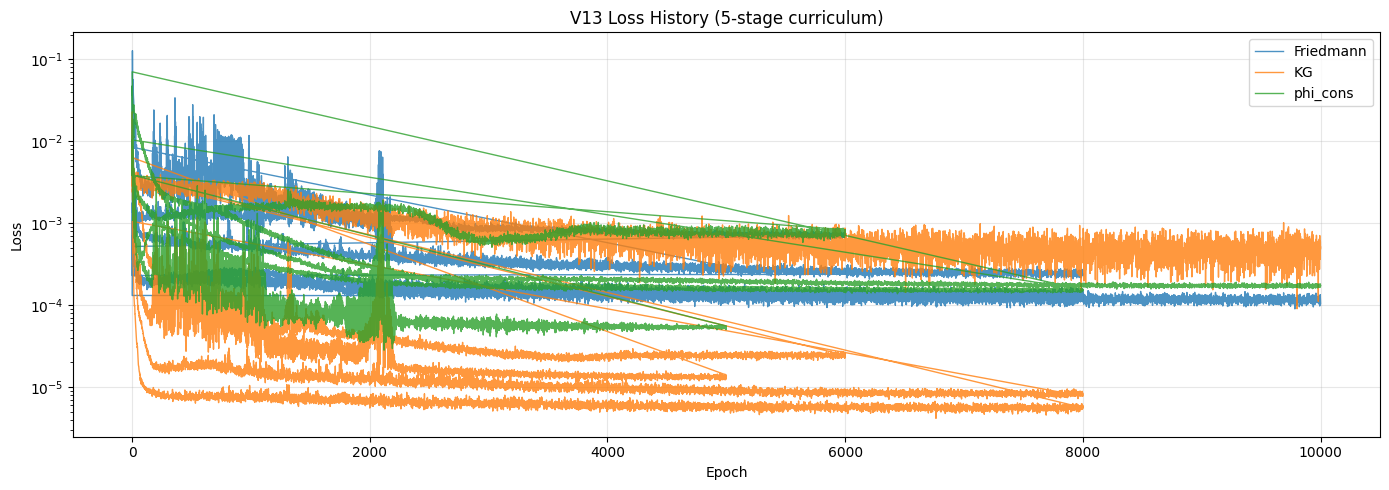

Saved: c:\Users\771754\Documents\Works\New_ver_PINNs_axion\PINNs_axion\results_v13\v13_loss.png


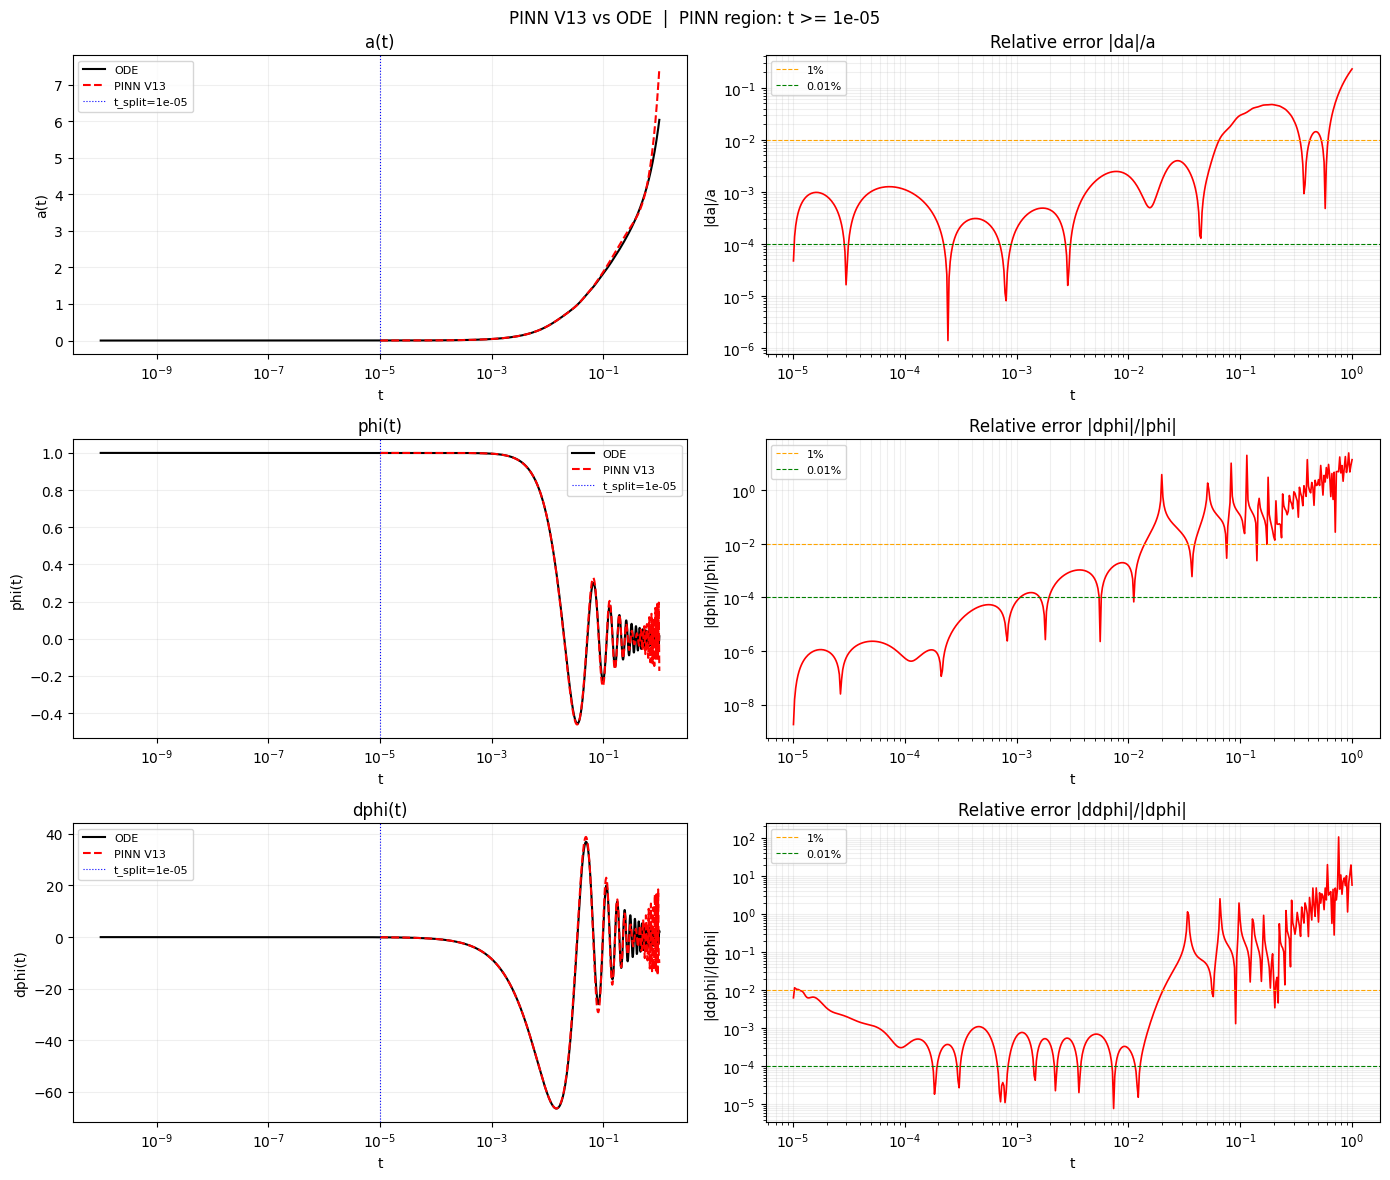

Saved: c:\Users\771754\Documents\Works\New_ver_PINNs_axion\PINNs_axion\results_v13\v13_comparison.png

PINN region (t >= 1e-05) summary:
  a(t)   median=9.77e-04  90th=3.65e-02
  phi(t) 90th  =6.42e-01
  dphi   90th  =7.05e-01

┌─────────────────────────┬─────────────┬─────────────┐
│ Region                  │  a(t) 90th% │ phi(t) 90th%│
├─────────────────────────┼─────────────┼─────────────┤
│ New: [1e-5, 1e-4]        │  1.23e-03   │  2.21e-06   │
│ New: [1e-4, 1e-3]        │  8.39e-04   │  5.17e-05   │
│ V12: [1e-3, 1e-2]        │  2.38e-03   │  1.69e-03   │
│ V12: [1e-2, 1.0 ]        │  4.71e-02   │  4.26e+00   │
└─────────────────────────┴─────────────┴─────────────┘


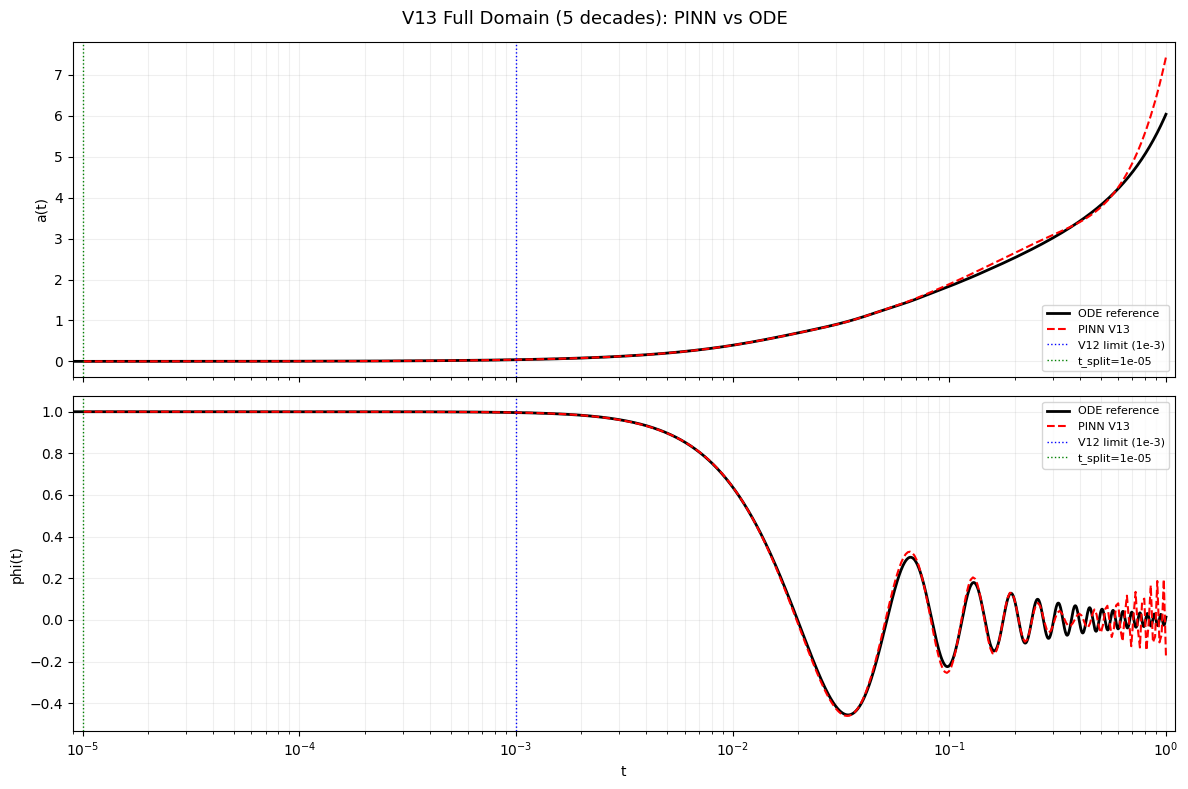

Saved: c:\Users\771754\Documents\Works\New_ver_PINNs_axion\PINNs_axion\results_v13\v13_full_domain.png


In [9]:
# ── EVALUATION & PLOTS ──────────────────────────────────────────────────────
plot_loss_v13(solver_v13, save_dir=RESULTS_DIR_V13)
plot_comparison_v13(solver_v13, save_dir=RESULTS_DIR_V13)

# ── Region breakdown: compare [1e-5, 1e-3] vs [1e-3, 1] ──────────────────
t_eval, a_pred, phi_pred, dphi_pred = solver_v13.evaluate()
t_ode, a_ode, phi_ode, dphi_ode = solver_v13.t_ode, solver_v13.a_ode, solver_v13.phi_ode, solver_v13.dphi_ode

a_ref    = np.interp(t_eval, t_ode, a_ode)
phi_ref  = np.interp(t_eval, t_ode, phi_ode)
rel_a    = np.abs(a_pred - a_ref)   / (np.abs(a_ref)   + 1e-30)
rel_phi  = np.abs(phi_pred - phi_ref) / (np.abs(phi_ref) + 1e-30)

breakpoints = [(1e-5, 1e-4, 'New: [1e-5, 1e-4]'),
               (1e-4, 1e-3, 'New: [1e-4, 1e-3]'),
               (1e-3, 1e-2, 'V12: [1e-3, 1e-2]'),
               (1e-2, 1.0,  'V12: [1e-2, 1.0 ]')]

print("\n┌─────────────────────────┬─────────────┬─────────────┐")
print("│ Region                  │  a(t) 90th% │ phi(t) 90th%│")
print("├─────────────────────────┼─────────────┼─────────────┤")
for t_lo, t_hi, label in breakpoints:
    mask = (t_eval >= t_lo) & (t_eval < t_hi)
    if mask.sum() < 5:
        print(f"│ {label:<23}  │     ---     │     ---     │")
        continue
    a90   = np.percentile(rel_a[mask],   90)
    phi90 = np.percentile(rel_phi[mask], 90)
    print(f"│ {label:<23}  │  {a90:.2e}   │  {phi90:.2e}   │")
print("└─────────────────────────┴─────────────┴─────────────┘")

# Full domain plot focusing on new region t in [1e-5, 1e-3]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, yp, yo, lab in zip(axes,
                            [a_pred, phi_pred], [a_ode, phi_ode], ['a(t)', 'phi(t)']):
    ax.semilogx(t_ode, yo, 'k-', lw=2, label='ODE reference')
    mask_all = t_eval >= solver_v13.T_SPLIT
    ax.semilogx(t_eval[mask_all], yp[mask_all], 'r--', lw=1.5, label='PINN V13')
    ax.axvline(1e-3, color='blue', ls=':', lw=1, label='V12 limit (1e-3)')
    ax.axvline(solver_v13.T_SPLIT, color='green', ls=':', lw=1, label=f't_split={solver_v13.T_SPLIT:.0e}')
    ax.set_ylabel(lab); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.2)
    ax.set_xlim([solver_v13.T_SPLIT * 0.9, 1.1])
axes[-1].set_xlabel('t')
fig.suptitle('V13 Full Domain (5 decades): PINN vs ODE', fontsize=13)
plt.tight_layout()
path_full = os.path.join(RESULTS_DIR_V13, 'v13_full_domain.png')
plt.savefig(path_full, dpi=150, bbox_inches='tight'); plt.show()
print(f"Saved: {path_full}")
